# Pathology Embedding Analysis — All Models

This notebook extends the original `Pathology_Embedding_Analysis.ipynb` to evaluate **all five embedding models** (Autoencoder, VAE, Contrastive VAE, DVAE, D-CVAE) on healthy vs. pathological gait data. It mirrors the multi-model workflow from `Embedding_Space_Analysis.ipynb`, enabling side-by-side comparisons across:

- Embedding extraction and dimensionality reduction
- Visualization of conditions (normal, bag, coat, pathological classes)
- Binary anomaly detection (healthy vs. pathological)
- Multi-class classification across pathology types

Adjust the configuration cells below to point to your checkpoints or to enable/disable specific models.


In [1]:
# Setup and imports
import os
import sys
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Computer vision
from PIL import Image

# ML / visualization utilities
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import euclidean_distances

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

# Ensure we can import local packages
NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR.parent  # gait/
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / 'models') not in sys.path:
    sys.path.insert(0, str(ROOT / 'models'))
if str(ROOT / 'models' / 'vae') not in sys.path:
    sys.path.insert(0, str(ROOT / 'models' / 'vae'))
if str(ROOT / 'preprocessing') not in sys.path:
    sys.path.insert(0, str(ROOT / 'preprocessing'))


Using device: cuda
PyTorch version: 2.5.1+cu121


In [2]:
# Model configuration and loading
from models.autoencoder.model import create_autoencoder
from models.vae.model import create_vae
from models.vae.contrastive_model import create_contrastive_vae
from models.vae.dvae_model import create_dvae
from models.vae.dcvae_model import create_dcvae

MODEL_CONFIG = {
    'autoencoder': {
        'enabled': True,
        'path': ROOT / 'models' / 'best_model.pth',
        'loader': lambda: create_autoencoder(embedding_dim=128),
        'type': 'autoencoder'
    },
    'vae': {
        'enabled': True,
        'path': ROOT / 'models' / 'best_model_vae.pth',
        'loader': lambda: create_vae(latent_dim=128),
        'type': 'vae'
    },
    'cvae': {
        'enabled': True,
        'path': ROOT / 'models' / 'vae' / 'checkpoints_contrastive' / 'best_model.pth',
        'loader': lambda: create_contrastive_vae(latent_dim=128, projection_dim=128),
        'type': 'contrastive'
    },
    'dvae': {
        'enabled': True,
        'path': ROOT / 'models' / 'vae' / 'checkpoints_dvae' / 'best_model.pth',
        'loader': lambda: create_dvae(latent_dim=128),
        'type': 'dvae'
    },
    'dcvae': {
        'enabled': True,
        'path': ROOT / 'models' / 'vae' / 'checkpoints_dcvae' / 'best_model.pth',
        'loader': lambda: create_dcvae(latent_dim=128, projection_dim=128),
        'type': 'dcvae'
    }
}

loaded_models = {}

for key, cfg in MODEL_CONFIG.items():
    if not cfg['enabled']:
        continue
    print(f"\nLoading {key.upper()} ...")
    model = cfg['loader']()
    ckpt_path = cfg['path']
    if ckpt_path.exists():
        ckpt = torch.load(ckpt_path, map_location=device)
        state = ckpt.get('model_state_dict', ckpt)
        missing, unexpected = model.load_state_dict(state, strict=False)
        if missing:
            print(f"   ⚠️ Missing keys: {missing[:5]} ...")
        if unexpected:
            print(f"   ⚠️ Unexpected keys: {unexpected[:5]} ...")
        model = model.to(device)
        model.eval()
        epoch = ckpt.get('epoch', 'N/A')
        print(f"   ✅ Loaded from {ckpt_path.name} (epoch={epoch})")
    else:
        print(f"   ⚠️ Checkpoint not found at {ckpt_path}. Model will remain randomly initialized.")
        model = model.to(device)
        model.eval()
    loaded_models[key] = model

print(f"\nModels ready: {list(loaded_models.keys())}")



Loading AUTOENCODER ...
   ✅ Loaded from best_model.pth (epoch=44)

Loading VAE ...
   ✅ Loaded from best_model_vae.pth (epoch=49)

Loading CVAE ...
   ✅ Loaded from best_model.pth (epoch=50)

Loading DVAE ...
   ✅ Loaded from best_model.pth (epoch=50)

Loading DCVAE ...
   ✅ Loaded from best_model.pth (epoch=20)

Models ready: ['autoencoder', 'vae', 'cvae', 'dvae', 'dcvae']


In [22]:
# Data ingestion: healthy CASIA-B + pathology datasets
CASIA_IMAGES_ROOT = ROOT / 'Casia-B-Images' / 'output'
PATHOLOGY_ROOT = Path(r"C:\Users\User\Documents\UNI\CV1\newdata")  # adjust if needed

PATHOLOGY_CLASS_MAP = {
    'Normal': 'normal',
    'Parkinson': 'parkinson',
    'Hemiplegic': 'hemiplegic',
    'Diplegic': 'diplegic',
    'Neuropathic': 'neuropathic'
}
import fnmatch

# def collect_casia_samples(images_root, max_subjects=40, max_images_per_subject=20):
#     samples = {'paths': [], 'subjects': [], 'conditions': []}
#     images_root = Path(images_root)
#     if not images_root.exists():
#         print(f"⚠️ CASIA directory not found: {images_root}")
#         return samples
#     subject_dirs = sorted([d for d in images_root.iterdir() if d.is_dir()])[:max_subjects]
#     for subj_dir in subject_dirs:
#         subj_id = subj_dir.name
#         img_files = sorted(list(subj_dir.rglob('*.png')))[:max_images_per_subject]
#         for img_path in img_files:
#             samples['paths'].append(img_path)
#             samples['subjects'].append(f"casia_{subj_id}")
#             samples['conditions'].append('normal')
#     print(f"CASIA samples: {len(samples['paths'])} images from {len(set(samples['subjects']))} subjects")
#     return samples


def collect_pathology_samples(root, max_subjects_per_condition=20, max_images_per_seq=25):
    samples = {'paths': [], 'subjects': [], 'conditions': []}
    root = Path(root)
    if not root.exists():
        print(f"⚠️ Pathology root not found: {root}")
        return samples

    for condition_dir in sorted(d for d in root.iterdir() if d.is_dir()):
        condition_name = condition_dir.name
        mapped_condition = PATHOLOGY_CLASS_MAP.get(condition_name, condition_name.lower())

        subject_dirs = sorted(d for d in condition_dir.iterdir() if d.is_dir())[:max_subjects_per_condition]
        for subj_dir in subject_dirs:
            subj_id = subj_dir.name
            gei_root = subj_dir / "GEIs" / "side_view"
            if not gei_root.exists():
                continue

            # Each sequence folder (e.g., s1pat2lvl1-1_back)
            for seq_dir in sorted(gei_root.rglob("*")):
                if not seq_dir.is_dir() or not fnmatch.fnmatch(seq_dir.name, "*_front"):
                    continue
                img_files = sorted(seq_dir.glob("*.jpg"))
                if not img_files:
                    continue

                count = 0
                for img_path in img_files:
                    # Skip the reference full.jpg if you only want GEIs, or keep both
                    samples['paths'].append(img_path)
                    samples['subjects'].append(f"{condition_name}_{subj_id}")
                    samples['conditions'].append(mapped_condition)
                    count += 1
                    if count >= max_images_per_seq:
                        break
    return samples

# healthy_samples = collect_casia_samples(CASIA_IMAGES_ROOT, max_subjects=40, max_images_per_subject=20)
# pathology_samples = collect_pathology_samples(PATHOLOGY_ROOT)
pathology_samples = collect_pathology_samples(PATHOLOGY_ROOT,
                                              max_subjects_per_condition=15,
                                              max_images_per_seq=30)

# pathology_samples = collect_pathology_samples(PATHOLOGY_ROOT, ...)

all_paths = pathology_samples['paths']
all_subjects = pathology_samples['subjects']
all_conditions = pathology_samples['conditions']
is_pathological = [0 if cond == 'normal' else 1 for cond in all_conditions]

# all_paths = healthy_samples['paths'] + pathology_samples['paths']
# all_subjects = healthy_samples['subjects'] + pathology_samples['subjects']
# all_conditions = healthy_samples['conditions'] + pathology_samples['conditions']
# is_pathological = [0] * len(healthy_samples['paths']) + [1] * len(pathology_samples['paths'])

# print(f"Total samples: {len(all_paths)} (healthy={len(healthy_samples['paths'])}, pathology={len(pathology_samples['paths'])})")
healthy_count = sum(cond == 'normal' for cond in all_conditions)
pathology_count = len(all_conditions) - healthy_count

print(f"Total samples: {len(all_paths)} "
      f"(healthy={healthy_count}, pathology={pathology_count})")


Total samples: 1639 (healthy=103, pathology=1536)


In [23]:
# Helper functions for preprocessing and embedding extraction
def load_and_preprocess_image(image_path, target_size=(128, 64)):
    img = Image.open(image_path).convert('L')
    img = img.resize(target_size, Image.LANCZOS)
    arr = np.array(img, dtype=np.float32) / 255.0
    tensor = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0)
    return tensor


def extract_embeddings(model_key, model, image_paths, use_projection=False, batch_size=32):
    embeddings = []
    model_type = MODEL_CONFIG[model_key]['type']
    model.eval()
    with torch.no_grad():
        for idx in range(0, len(image_paths), batch_size):
            batch_paths = image_paths[idx:idx + batch_size]
            batch_tensors = [load_and_preprocess_image(p) for p in batch_paths]
            batch = torch.cat(batch_tensors, dim=0).to(device)

            if model_type == 'autoencoder':
                emb = model.encode(batch)
            elif model_type == 'vae':
                mu, _ = model.encode(batch)
                emb = mu
            elif model_type == 'contrastive':
                if use_projection:
                    proj, _, _ = model.get_projection(batch)
                    emb = proj
                else:
                    emb = model.get_embedding(batch)
            elif model_type == 'dvae':
                _, mu, _ = model.forward_clean(batch)
                emb = mu
            elif model_type == 'dcvae':
                if use_projection:
                    _, mu, _, proj = model.forward_clean(batch, return_projection=True)
                    emb = proj
                else:
                    _, mu, _ = model.forward_clean(batch, return_projection=False)
                    emb = mu
            else:
                raise ValueError(f"Unsupported model type: {model_type}")

            embeddings.append(emb.cpu().numpy())
    if not embeddings:
        return np.empty((0, 128), dtype=np.float32)
    return np.concatenate(embeddings, axis=0)


def tsne_2d(embeddings, perplexity=35, random_state=42):
    if len(embeddings) < 3:
        return np.zeros((len(embeddings), 2))
    tsne = TSNE(n_components=2, perplexity=min(perplexity, len(embeddings) - 1), random_state=random_state)
    return tsne.fit_transform(embeddings)



In [24]:
# Extract embeddings for every enabled model
all_paths_array = list(all_paths)
conditions_array = np.array(all_conditions)
subjects_array = np.array(all_subjects)
is_pathological_array = np.array(is_pathological)

embeddings_dict = {}
embeddings_2d_dict = {}

for key, model in loaded_models.items():
    print(f"\nExtracting embeddings with {key.upper()} ...")
    use_proj = key in {'cvae', 'dcvae'}  # default to projection space for contrastive models
    emb = extract_embeddings(key, model, all_paths_array, use_projection=use_proj, batch_size=32)
    embeddings_dict[key] = emb
    embeddings_2d_dict[key] = tsne_2d(emb, perplexity=35)
    print(f"   Shape: {emb.shape}")

print("\nFinished computing embeddings for:", list(embeddings_dict.keys()))



Extracting embeddings with AUTOENCODER ...
   Shape: (1639, 128)

Extracting embeddings with VAE ...
   Shape: (1639, 128)

Extracting embeddings with CVAE ...
   Shape: (1639, 128)

Extracting embeddings with DVAE ...
   Shape: (1639, 128)

Extracting embeddings with DCVAE ...
   Shape: (1639, 128)

Finished computing embeddings for: ['autoencoder', 'vae', 'cvae', 'dvae', 'dcvae']


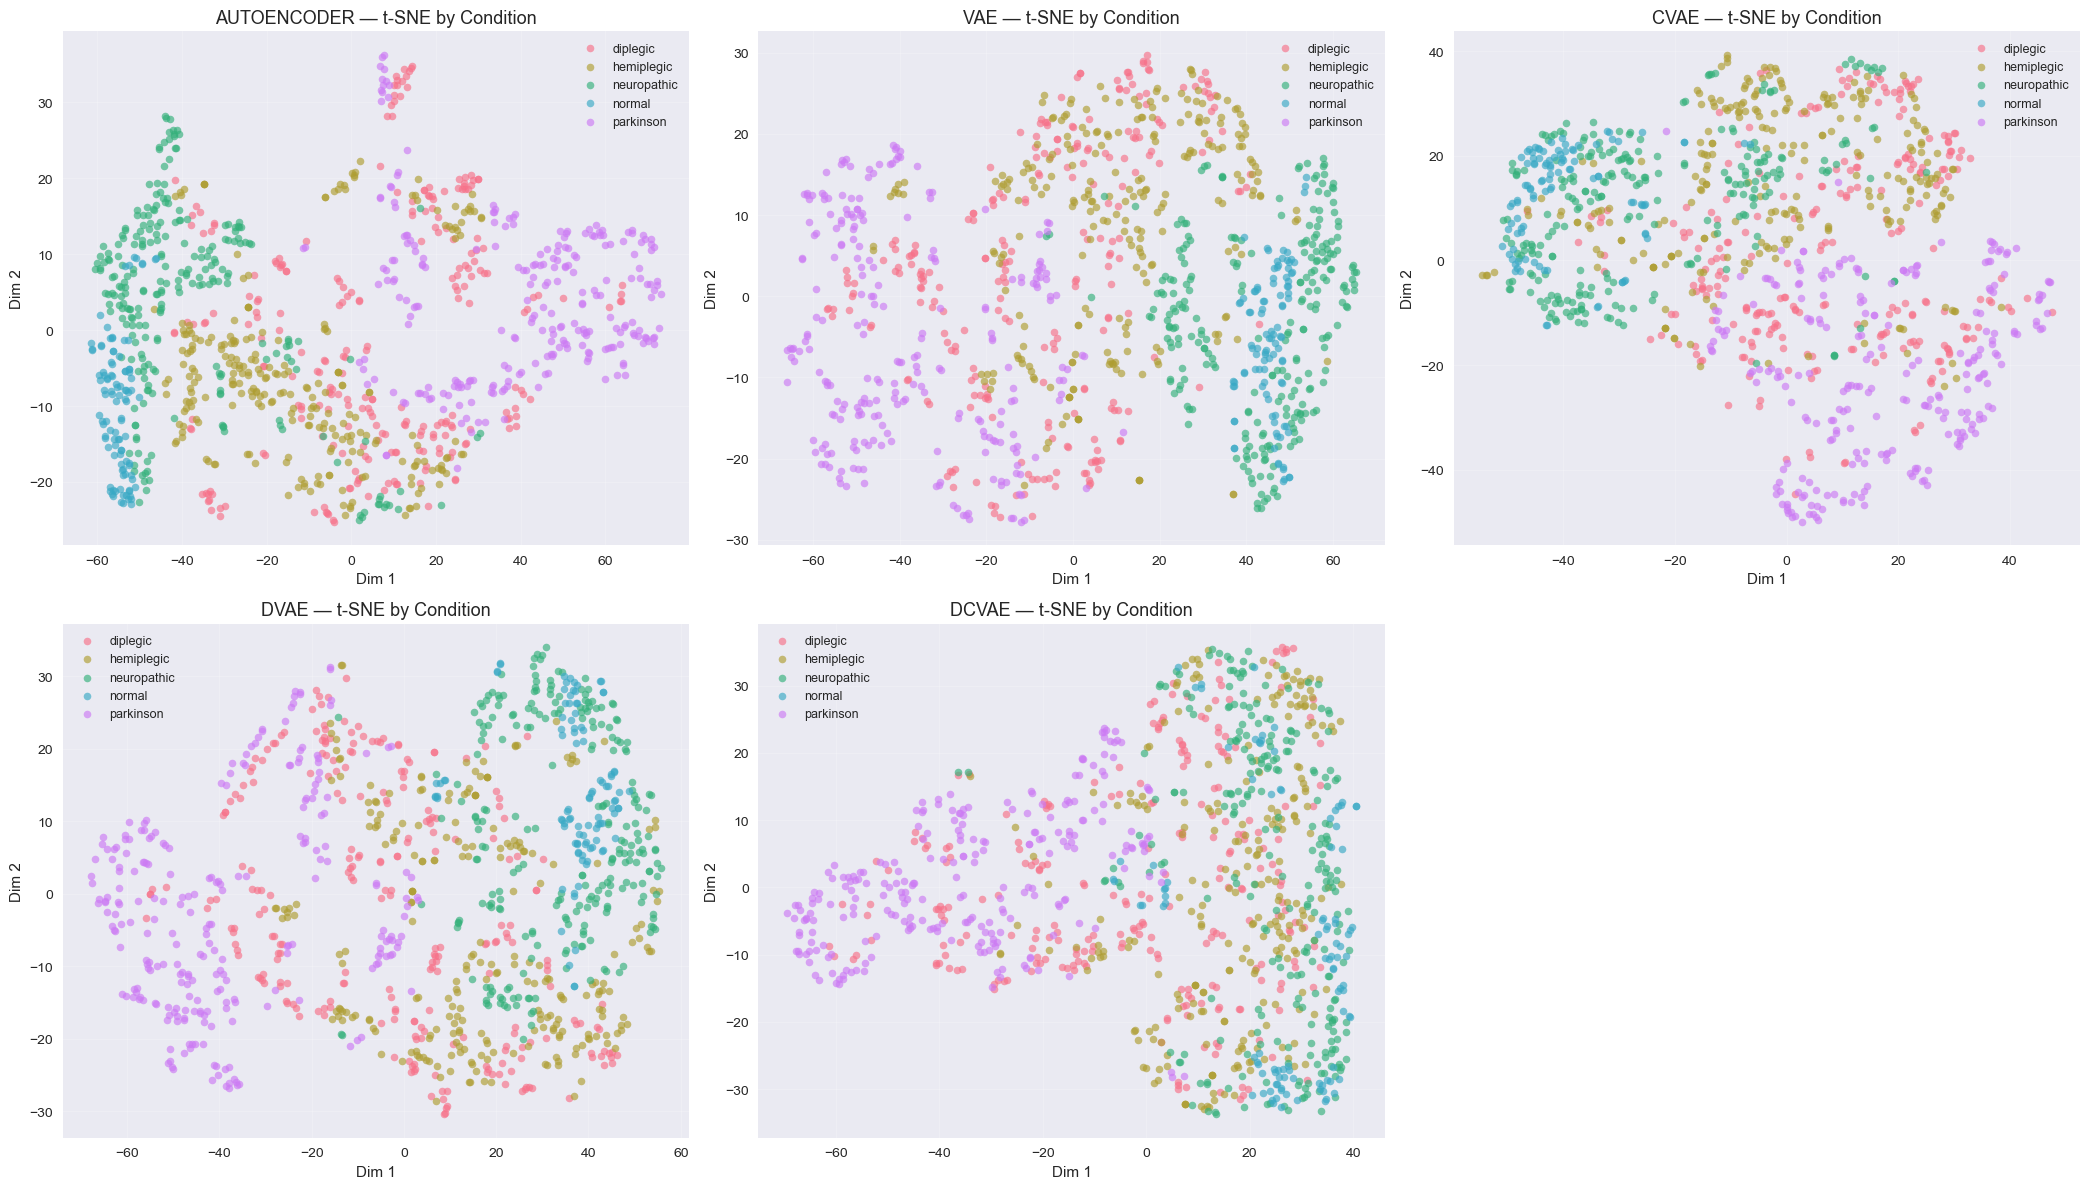

In [25]:
# Visualization: t-SNE by condition for all models
unique_conditions = sorted(set(conditions_array))
condition_colors = {cond: color for cond, color in zip(unique_conditions, sns.color_palette('husl', len(unique_conditions)))}

SUBSAMPLE_PER_CLASS = 250
rng = np.random.default_rng(42)

def build_condition_mask(cond_array):
    keep = np.zeros(len(cond_array), dtype=bool)
    for cond in unique_conditions:
        idx = np.where(cond_array == cond)[0]
        if len(idx) == 0:
            continue
        if len(idx) > SUBSAMPLE_PER_CLASS:
            idx = rng.choice(idx, size=SUBSAMPLE_PER_CLASS, replace=False)
        keep[idx] = True
    return keep

cond_mask = build_condition_mask(conditions_array)
conditions_subset = conditions_array[cond_mask]

n_models = len(embeddings_2d_dict)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, (key, coords) in zip(axes, embeddings_2d_dict.items()):
    coords_subset = coords[cond_mask]
    for cond in unique_conditions:
        mask = conditions_subset == cond
        if mask.sum() == 0:
            continue
        ax.scatter(coords_subset[mask, 0], coords_subset[mask, 1],
                   c=[condition_colors[cond]], label=cond, alpha=0.65, s=30, linewidths=0)
    ax.set_title(f"{key.upper()} — t-SNE by Condition", fontsize=13)
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=9, loc='best')

for ax in axes[n_models:]:
    ax.axis('off')

plt.tight_layout()
plt.show()


In [26]:
# Classification helpers

def make_balanced_binary(labels_array, positive_label=1, random_state=42):
    labels_array = np.array(labels_array)
    pos_idx = np.where(labels_array == positive_label)[0]
    neg_idx = np.where(labels_array != positive_label)[0]
    target = min(len(pos_idx), len(neg_idx))
    rng = np.random.default_rng(random_state)
    pos_sel = rng.choice(pos_idx, size=target, replace=False)
    neg_sel = rng.choice(neg_idx, size=target, replace=False)
    selected = np.concatenate([pos_sel, neg_sel])
    rng.shuffle(selected)
    return selected


def eval_binary_classifier(embeddings, labels, name='model'):
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, labels, test_size=0.2, random_state=42, stratify=labels
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} — Binary Healthy vs Pathology")
    print(f"Accuracy: {acc:.3f}")
    print(classification_report(y_test, y_pred, target_names=['healthy', 'pathological']))
    return acc


def make_balanced_multi(conditions, max_per_class=None, random_state=42):
    cond_array = np.array(conditions)
    rng = np.random.default_rng(random_state)
    idx_by_cond = defaultdict(list)
    for i, cond in enumerate(cond_array):
        idx_by_cond[cond].append(i)
    counts = {cond: len(idx) for cond, idx in idx_by_cond.items()}
    if max_per_class is None:
        target = min(counts.values())
    else:
        target = min(max_per_class, min(counts.values()))
    selected = []
    for cond, idxs in idx_by_cond.items():
        if len(idxs) > target:
            idxs = rng.choice(idxs, size=target, replace=False)
        selected.append(np.array(idxs))
    selected = np.concatenate(selected)
    rng.shuffle(selected)
    return selected


def eval_multiclass_classifier(embeddings, labels, name='model'):
    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(labels)
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    clf = LogisticRegression(max_iter=2000, multi_class='multinomial')
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} — Multi-class Conditions")
    print(f"Accuracy: {acc:.3f}")
    print(classification_report(y_test, y_pred, target_names=encoder.classes_))
    return acc


In [27]:
# Binary healthy vs pathology evaluation
BALANCED_IDX = make_balanced_binary(is_pathological_array, positive_label=1, random_state=42)
y_binary = is_pathological_array[BALANCED_IDX]

binary_results = {}
for key, emb in embeddings_dict.items():
    emb_bal = emb[BALANCED_IDX]
    acc = eval_binary_classifier(emb_bal, y_binary, name=f'{key.upper()} (balanced)')
    binary_results[key] = acc

binary_results



AUTOENCODER (balanced) — Binary Healthy vs Pathology
Accuracy: 1.000
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00        21
pathological       1.00      1.00      1.00        21

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42


VAE (balanced) — Binary Healthy vs Pathology
Accuracy: 1.000
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00        21
pathological       1.00      1.00      1.00        21

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42


CVAE (balanced) — Binary Healthy vs Pathology
Accuracy: 1.000
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00        21
pathological       1.00      1.00      1.0

{'autoencoder': 1.0,
 'vae': 1.0,
 'cvae': 1.0,
 'dvae': 1.0,
 'dcvae': 0.9523809523809523}

In [28]:
# Multi-class condition classification
MULTI_IDX = make_balanced_multi(conditions_array, max_per_class=150, random_state=21)
conditions_balanced = conditions_array[MULTI_IDX]

multiclass_results = {}
for key, emb in embeddings_dict.items():
    emb_bal = emb[MULTI_IDX]
    acc = eval_multiclass_classifier(emb_bal, conditions_balanced, name=f'{key.upper()} (balanced)')
    multiclass_results[key] = acc

multiclass_results



AUTOENCODER (balanced) — Multi-class Conditions
Accuracy: 0.868
              precision    recall  f1-score   support

    diplegic       0.75      0.69      0.72        26
  hemiplegic       0.79      0.88      0.83        25
 neuropathic       0.96      0.85      0.90        26
      normal       0.93      1.00      0.96        26
   parkinson       0.92      0.92      0.92        26

    accuracy                           0.87       129
   macro avg       0.87      0.87      0.87       129
weighted avg       0.87      0.87      0.87       129


VAE (balanced) — Multi-class Conditions
Accuracy: 0.868
              precision    recall  f1-score   support

    diplegic       0.83      0.73      0.78        26
  hemiplegic       0.72      0.84      0.78        25
 neuropathic       0.92      0.85      0.88        26
      normal       0.93      1.00      0.96        26
   parkinson       0.96      0.92      0.94        26

    accuracy                           0.87       129
   macro 

{'autoencoder': 0.8682170542635659,
 'vae': 0.8682170542635659,
 'cvae': 0.7209302325581395,
 'dvae': 0.8449612403100775,
 'dcvae': 0.6976744186046512}

In [29]:
# Summary table
summary_df = pd.DataFrame({
    'model': list(binary_results.keys()),
    'binary_acc': [binary_results[k] for k in binary_results.keys()],
    'multiclass_acc': [multiclass_results.get(k, np.nan) for k in binary_results.keys()]
})
summary_df


,model,binary_acc,multiclass_acc
0,autoencoder,1.000000,0.868217
1,vae,1.000000,0.868217
2,cvae,1.000000,0.720930
3,dvae,1.000000,0.844961
4,dcvae,0.952381,0.697674


In [30]:
from sklearn.neighbors import KNeighborsClassifier

def eval_subject_nn(embeddings, subjects, k=1, min_samples=3, name='model'):
    subjects = np.array(subjects)
    unique_subjects = [s for s in np.unique(subjects) if np.sum(subjects == s) >= min_samples]
    mask = np.isin(subjects, unique_subjects)
    emb = embeddings[mask]
    subj = subjects[mask]

    X_train, X_test, y_train, y_test = train_test_split(
        emb, subj, test_size=0.3, random_state=42, stratify=subj
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    knn.fit(X_train_s, y_train)
    y_pred = knn.predict(X_test_s)

    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} — Subject NN@{k}")
    print(f"Accuracy: {acc:.3f}")
    print(classification_report(y_test, y_pred))
    return acc

In [31]:
subject_results = {}
for key, emb in embeddings_dict.items():
    acc = eval_subject_nn(emb, subjects_array, k=1, name=f'{key.upper()}')
    subject_results[key] = acc
subject_results


AUTOENCODER — Subject NN@1
Accuracy: 0.823
                 precision    recall  f1-score   support

    Diplegic_s1       1.00      0.83      0.91         6
   Diplegic_s10       0.90      0.90      0.90        10
   Diplegic_s11       1.00      0.50      0.67         8
   Diplegic_s12       0.88      1.00      0.93         7
   Diplegic_s13       0.75      0.50      0.60         6
   Diplegic_s14       0.86      1.00      0.92         6
   Diplegic_s15       1.00      0.88      0.93         8
   Diplegic_s16       1.00      0.83      0.91         6
   Diplegic_s17       0.89      0.89      0.89         9
   Diplegic_s18       0.60      0.75      0.67         8
   Diplegic_s19       0.73      0.89      0.80         9
    Diplegic_s2       1.00      1.00      1.00         6
   Diplegic_s20       0.64      0.78      0.70         9
   Diplegic_s21       0.86      0.86      0.86         7
   Diplegic_s22       0.88      0.78      0.82         9
  Hemiplegic_s1       1.00      0.40      0

{'autoencoder': 0.823170731707317,
 'vae': 0.8373983739837398,
 'cvae': 0.7378048780487805,
 'dvae': 0.8191056910569106,
 'dcvae': 0.5386178861788617}

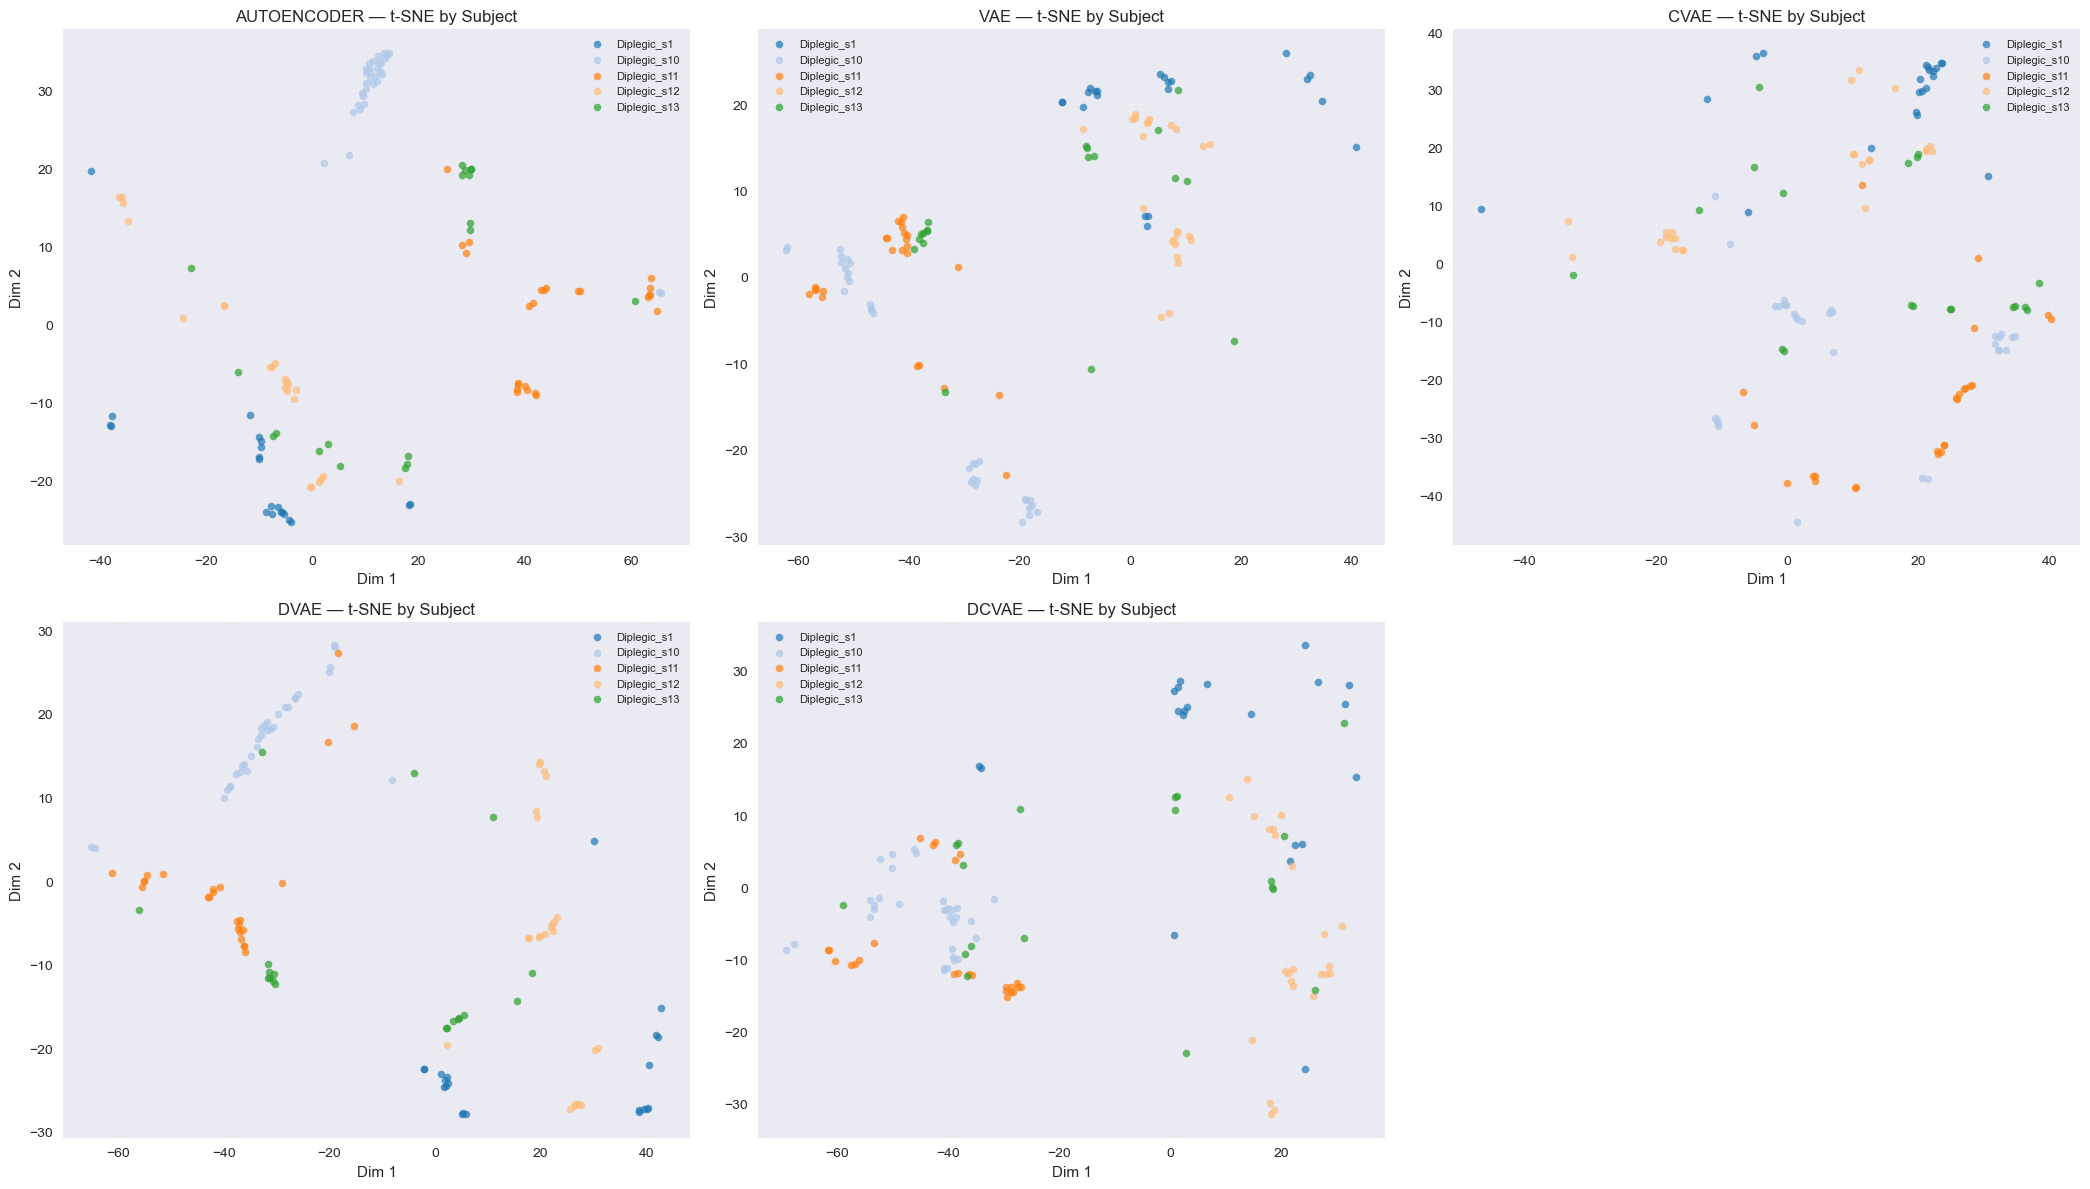

In [33]:
# Visualize embeddings by subject (subsample to keep it readable)
MAX_SUBJECTS = 5
subject_labels = np.array(subjects_array)
unique_subjects = sorted(set(subject_labels))
rng = np.random.default_rng(42)
selected_subjects = unique_subjects[:MAX_SUBJECTS]  # or randomly sample

subject_mask = np.isin(subject_labels, selected_subjects)
subject_subset = subject_labels[subject_mask]

n_models = len(embeddings_2d_dict)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows))
axes = np.atleast_1d(axes).flatten()

color_map = {subj: color for subj, color in zip(selected_subjects, sns.color_palette('tab20', len(selected_subjects)))}

for ax, (key, coords) in zip(axes, embeddings_2d_dict.items()):
    coords_subset = coords[subject_mask]
    for subj in selected_subjects:
        mask = subject_subset == subj
        if mask.sum() == 0:
            continue
        ax.scatter(coords_subset[mask, 0], coords_subset[mask, 1],
                   c=[color_map[subj]], label=subj, alpha=0.7, s=30, linewidths=0)
    ax.set_title(f'{key.upper()} — t-SNE by Subject')
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8, loc='best')

for ax in axes[n_models:]:
    ax.axis('off')

plt.tight_layout()
plt.show()